<a href="https://colab.research.google.com/github/alecbidaran/Pytorch_excersies/blob/main/Policy_Gradient(Best_version).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gym
!apt-get install python-opengl -y
!apt install xvfb -y
!pip install gym[atari]
!pip install pyvirtualdisplay
!pip install piglet
!pip install torch torchvision torchaudio


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Reading package lists... Done
Building dependency tree       
Reading state information... Done
python-opengl is already the newest version (3.1.0+dfsg-2build1).
0 upgraded, 0 newly installed, 0 to remove and 23 not upgraded.
Reading package lists... Done
Building dependency tree       
Reading state information... Done
xvfb is already the newest version (2:1.20.13-1ubuntu1~20.04.6).
0 upgraded, 0 newly installed, 0 to remove and 23 not upgraded.
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import gym
import collections
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

In [ ]:
torch.__version__

'1.13.1+cu116'

In [ ]:
import pyvirtualdisplay


_display = pyvirtualdisplay.Display(visible=False,  # use False with Xvfb
                                    size=(1400, 900))
_ = _display.start()

In [ ]:
env = gym.make("CartPole-v0")
GAMMA = 0.99
LEARNING_RATE = 0.01
EPISODES_TO_TRAIN = 4

/usr/local/lib/python3.9/dist-packages/gym/envs/registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
/usr/local/lib/python3.9/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.9/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [ ]:
class PGN(torch.nn.Module):
  def __init__(self,input_size,n_actions):
    super().__init__()
    self.net=torch.nn.Sequential(
        torch.nn.Linear(input_size,128),
        torch.nn.ReLU(),
        torch.nn.Linear(128,n_actions)
    )
  def forward(self,x):
    return self.net(x)

In [ ]:
def calc_qval(rewards):
  res=[]
  sum_r=0.0
  for r in reversed(rewards):
    sum_r*=GAMMA
    sum_r+=r
    res.append(sum_r)
  return list(reversed(res))


In [ ]:
## using Pytorch disturbution
action=torch.nn.functional.softmax(torch.randn(1,2),dim=-1)
disturbution=torch.distributions.categorical.Categorical(action)
action=disturbution.sample()
print(action)

tensor([0])


In [ ]:
disturbution.log_prob(action)

tensor([-0.8111])

In [ ]:
policy=PGN(env.observation_space.shape[0],env.action_space.n)
optimizer = torch.optim.Adam(policy.parameters(), lr=LEARNING_RATE)

In [ ]:
def train(policy,optimizer):
  policy.train()
  log_prob_actions = []
  rewards = []
  done = False
  episode_reward = 0
  state=env.reset()
  optimizer.zero_grad()
  while not done:
    state_v=torch.FloatTensor(list(state)).unsqueeze(0)
    pred_action=policy(state_v)
    pred_action=F.softmax(pred_action,dim=-1)
    dist=torch.distributions.categorical.Categorical(pred_action)
    action=dist.sample()
    logproba=dist.log_prob(action)
    log_prob_actions.append(logproba)
    state,reward,done,_=env.step(action.item())
    episode_reward+=reward
    rewards.append(reward)
  log_prob_v=torch.cat(log_prob_actions)
  rewards=calc_qval(rewards)
  rewards_v=torch.FloatTensor(rewards)
  logits=rewards_v*log_prob_v
  loss=-logits.mean()
  loss.backward()
  optimizer.step()
  return loss.item(),episode_reward,rewards


In [ ]:
total_rewards = []
step_idx = 0
done_episodes = 0
plot_rewards=[]
batch_episodes = 0
batch_states, batch_actions, batch_qvals = [], [], []
cur_states, cur_actions=[],[]
cur_rewards = []
solved=False
episode_idx=0
while not solved:
  episode_idx+=1
  loss,episode_reward,rewards=train(policy,optimizer)
  mean_rewards=np.mean(rewards[-100:])
  print("%d: , loss:%6.2f , reward: %6.2f, mean_100: %6.2f"%(
                episode_idx, loss ,episode_reward, mean_rewards))
  plot_rewards.append(episode_reward)
  if episode_reward > 195:
    print("Solved in %d steps and %d episodes!" % (step_idx, done_episodes))
    solved=True
    break




1: , loss:  2.20 , reward:   9.00, mean_100:   4.87
2: , loss:  8.21 , reward:  26.00, mean_100:  12.44
3: , loss:  2.47 , reward:  11.00, mean_100:   5.80
4: , loss:  3.23 , reward:  11.00, mean_100:   5.80
5: , loss:  2.24 , reward:  10.00, mean_100:   5.34
6: , loss:  0.76 , reward:   9.00, mean_100:   4.87
7: , loss:  3.62 , reward:  12.00, mean_100:   6.27
8: , loss:  0.61 , reward:  10.00, mean_100:   5.34
9: , loss:  2.41 , reward:  11.00, mean_100:   5.80
10: , loss:  1.56 , reward:  10.00, mean_100:   5.34
11: , loss:  2.33 , reward:  11.00, mean_100:   5.80
12: , loss:  2.36 , reward:  11.00, mean_100:   5.80
13: , loss:  5.49 , reward:  16.00, mean_100:   8.09
14: , loss:  3.93 , reward:  12.00, mean_100:   6.27
15: , loss:  2.37 , reward:  12.00, mean_100:   6.27
16: , loss:  0.57 , reward:   9.00, mean_100:   4.87
17: , loss:  3.74 , reward:  14.00, mean_100:   7.18
18: , loss:  3.45 , reward:  12.00, mean_100:   6.27
19: , loss:  1.86 , reward:   9.00, mean_100:   4.87
20

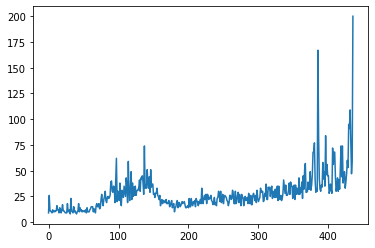

In [ ]:
plt.plot(plot_rewards)